# EDA multivariado

```{admonition} Alcance
:class: tip
Este capítulo usa solo el entrenamiento y la semilla 2026 en todo lo aleatorio. La matriz de diseño
del PCA, del Isolation Forest y de los conglomerados es la misma del modelo base: numéricas
estandarizadas y categóricas en una columna por categoría (las de menos de 300 filas se agrupan).
```

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
from comun import (cargar, particion, estilo, tasa_ic, v_cramer, OBJETIVO, NUM, BIN, CAT,
                   PREDICTORAS, SEMILLA, VERDE, ORO, TINTA, GRIS_CL, BORDE)

estilo()

tr, _ = particion(cargar())
rng = np.random.default_rng(SEMILLA)

## Correlación entre numéricas y binarias (Spearman)

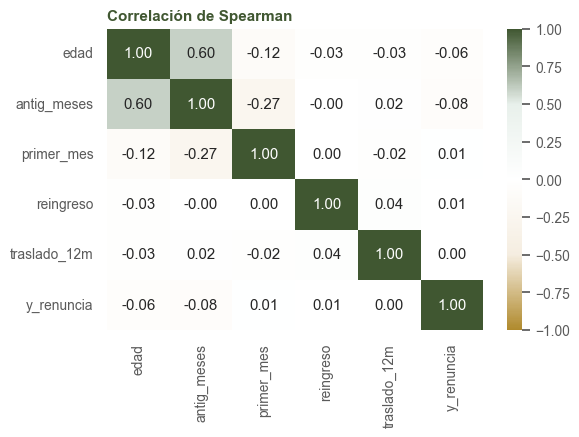

In [2]:
corr = tr[NUM + BIN + [OBJETIVO]].corr(method='spearman')

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='oro_verde', center=0, vmin=-1, vmax=1, ax=ax)
ax.set(title='Correlación de Spearman')
plt.tight_layout()
plt.show()

Edad y antigüedad tienen una correlación de rangos de 0,6, la única redundancia entre numéricas.
Las correlaciones con el objetivo son pequeñas en valor absoluto, como se espera con una clase del
1 %; para medir asociación con un evento raro son más adecuados el AUC y la información mutua.

## Asociación entre categóricas (V de Cramér)

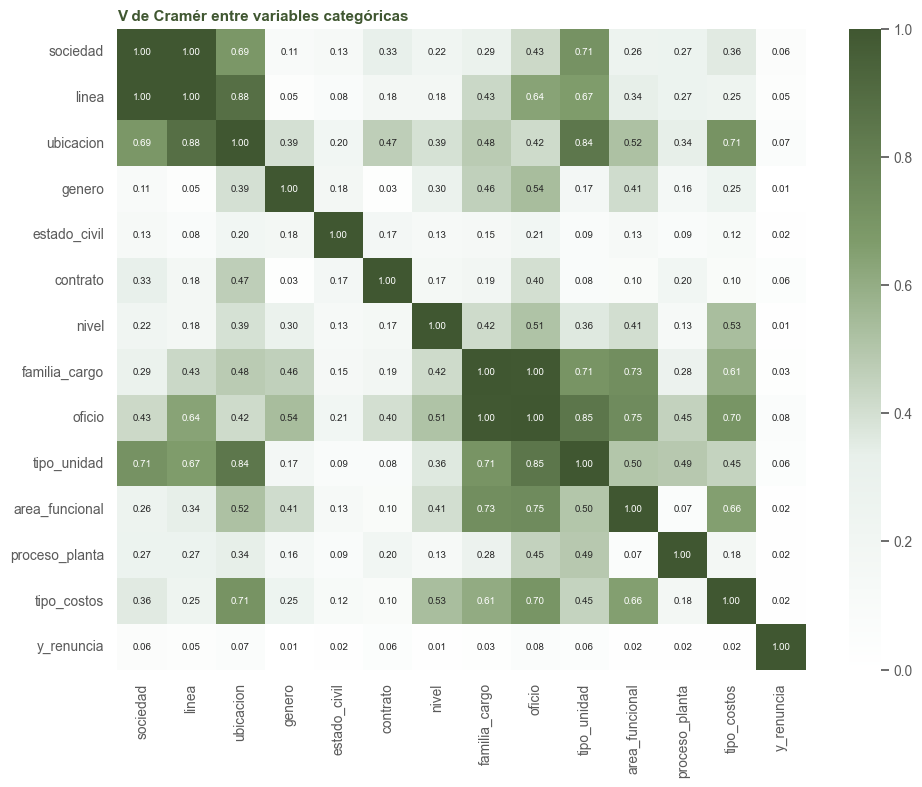

In [3]:
variables = CAT + [OBJETIVO]
V = pd.DataFrame(np.eye(len(variables)), index=variables, columns=variables)
for i, a in enumerate(variables):
    for b in variables[i + 1:]:
        V.loc[a, b] = V.loc[b, a] = v_cramer(tr[a], tr[b])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(V, annot=True, fmt='.2f', cmap='verde', vmin=0, vmax=1, ax=ax, annot_kws={'size': 7})
ax.set(title='V de Cramér entre variables categóricas')
plt.tight_layout()
plt.show()

Los dos pares con V = 1 corresponden a variables anidadas por construcción: cada sociedad pertenece
a una sola línea y cada oficio a una sola familia, de modo que la categoría fina determina la
gruesa. Además, `ubicacion` está casi anidada en `linea` (0,88) y `oficio` casi determina
`tipo_unidad` (0,85). Se conservan todas porque la predicción no se afecta (sección 4.3), pero al
interpretar importancias cada par debe leerse como una sola señal.

## Factor de inflación de la varianza (VIF)

El VIF de una columna mide cuánto se infla la varianza de su coeficiente porque las demás columnas
la explican: VIF = 1 / (1 − R²) al regresar esa columna contra el resto. Se calcula sobre la matriz
de una regresión logística, con las numéricas y variables indicadoras (se omite una categoría por
variable, la más frecuente; con una categoría rara como referencia el VIF se infla sin que haya
colinealidad real).

In [4]:
muestra = tr.sample(20000, random_state=SEMILLA)


def vif(cols_cat):
    d = muestra[NUM + BIN + cols_cat].fillna({'edad': muestra.edad.median()}).fillna('(nulo)')
    # la categoría más frecuente queda primera y get_dummies la omite como referencia
    for c in cols_cat:
        d[c] = pd.Categorical(d[c], categories=list(d[c].value_counts().index))
    X = add_constant(pd.get_dummies(d, columns=cols_cat, drop_first=True, dtype=float))
    valores = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return pd.Series(valores, index=X.columns).drop('const')


def variable_de(columna, variables):
    return next((v for v in variables if columna == v or columna.startswith(v + '_')), columna)


base = ['contrato', 'linea', 'tipo_unidad', 'tipo_costos', 'estado_civil', 'genero', 'nivel']
v1 = vif(base)
print('VIF con variables de baja cardinalidad (máximo por variable):')
maximos = v1.groupby(lambda c: variable_de(c, NUM + BIN + base)).max()
print(maximos.round(1).sort_values(ascending=False).to_string())

v2 = vif(base + ['sociedad'])
print('\nal agregar sociedad, VIF de las columnas de linea:')
print(v2[[c for c in v2.index if c.startswith('linea_')]].round(1).to_string())

VIF con variables de baja cardinalidad (máximo por variable):
tipo_unidad     4.3
linea           4.2
antig_meses     3.2
tipo_costos     2.7
contrato        2.6
nivel           2.1
edad            1.9
estado_civil    1.3
genero          1.2
traslado_12m    1.1
primer_mes      1.0
reingreso       1.0



al agregar sociedad, VIF de las columnas de linea:
linea_banano        inf
linea_industrial    inf
linea_transporte    inf
linea_puerto        inf
linea_ganaderia     inf


Con las variables de baja cardinalidad los VIF son moderados. Al agregar `sociedad`, el VIF de las
columnas de línea se vuelve infinito, porque cada indicadora de línea es la suma exacta de las
indicadoras de sus sociedades. La matriz no tiene rango completo y los coeficientes de una logística
sin penalización no están identificados.

```{admonition} Observación
:class: note
La colinealidad no cambia las predicciones. Para predecir se pueden conservar las dos variables de
cada par siempre que la logística esté regularizada (L2, la opción por defecto de scikit-learn),
que elige una solución única. Lo que no se puede hacer es interpretar sus coeficientes por separado.
```

## Componentes principales

Aplicamos PCA sobre la matriz de diseño estandarizada. Con tantas indicadoras es una aproximación
(para mezclas de numéricas y categóricas lo usual sería FAMD o análisis de correspondencias
múltiples), pero permite ver si la estructura principal de los datos separa a quienes renuncian.

columnas de la matriz: 170 | componentes para 50 % de la varianza: 23 | para 80 %: 63


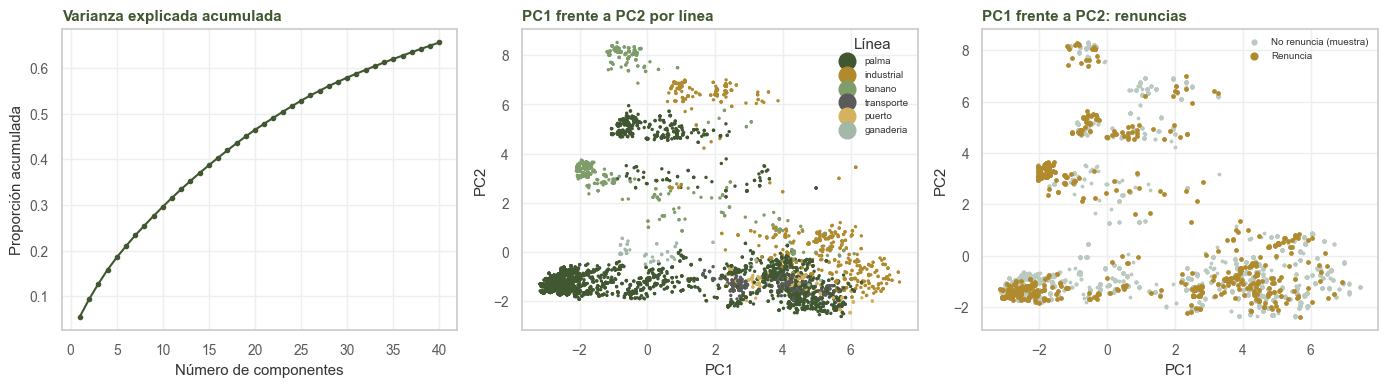

PC1 cargas más grandes: ['tipo_unidad_area_funcional', 'area_funcional_no_aplica', 'nivel_1_operativo', 'familia_cargo_agricola_campo', 'tipo_unidad_finca_palma', 'tipo_costos_OPERATIVO DIRECTO']
PC2 cargas más grandes: ['proceso_planta_no_aplica', 'familia_cargo_planta_industrial', 'tipo_unidad_planta_industrial', 'sociedad_S04', 'linea_banano', 'oficio_planta']


In [5]:
prep = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), NUM),
    ('bin', 'passthrough', BIN),
    ('cat', make_pipeline(
        SimpleImputer(strategy='constant', fill_value='(nulo)'),
        OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=300,
                      sparse_output=False),
    ), CAT),
])
X = prep.fit_transform(tr[PREDICTORAS])
y = tr[OBJETIVO].to_numpy()
Xs = StandardScaler().fit_transform(X)

pca = PCA(random_state=SEMILLA).fit(Xs)
var = pca.explained_variance_ratio_
print(f'columnas de la matriz: {X.shape[1]} | '
      f'componentes para 50 % de la varianza: {np.argmax(var.cumsum() >= 0.5) + 1} | '
      f'para 80 %: {np.argmax(var.cumsum() >= 0.8) + 1}')
Z = pca.transform(Xs)[:, :10]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(np.arange(1, 41), var[:40].cumsum(), marker='.', color=VERDE)
ax[0].set(title='Varianza explicada acumulada', xlabel='Número de componentes',
          ylabel='Proporción acumulada')

idx = rng.choice(len(Z), 8000, replace=False)
sns.scatterplot(x=Z[idx, 0], y=Z[idx, 1], hue=tr.linea.to_numpy()[idx], s=6, ax=ax[1],
                linewidth=0)
ax[1].set(title='PC1 frente a PC2 por línea', xlabel='PC1', ylabel='PC2')
ax[1].legend(title='Línea', fontsize=7, markerscale=2)

renuncia = y == 1
ax[2].scatter(Z[~renuncia, 0][:8000], Z[~renuncia, 1][:8000], s=3, c=GRIS_CL,
              label='No renuncia (muestra)')
ax[2].scatter(Z[renuncia, 0], Z[renuncia, 1], s=6, c=ORO, label='Renuncia')
ax[2].legend(fontsize=7, markerscale=2)
ax[2].set(title='PC1 frente a PC2: renuncias', xlabel='PC1', ylabel='PC2')
plt.tight_layout()
plt.show()

cargas = pd.DataFrame(pca.components_[:2].T, index=prep.get_feature_names_out(),
                      columns=['PC1', 'PC2'])
for k in ['PC1', 'PC2']:
    mayores = cargas[k].abs().sort_values(ascending=False).head(6).index
    print(k, 'cargas más grandes:', mayores.str.replace(r'^\w+__', '', regex=True).tolist())

La varianza está muy repartida: se necesitan muchos componentes para explicar la mitad, porque la
matriz está formada sobre todo por indicadoras casi independientes. Los dos primeros componentes
separan líneas de negocio y tipos de unidad, y las renuncias se reparten por todo el plano. La
estructura dominante de los datos es organizacional, y ningún eje lineal separa por sí solo a
quienes renuncian.

## Anomalías: Isolation Forest

Isolation Forest mide qué tan fácil es aislar una fila con cortes al azar; las filas raras se aíslan
rápido. Aquí interesa saber si las filas raras renuncian más.

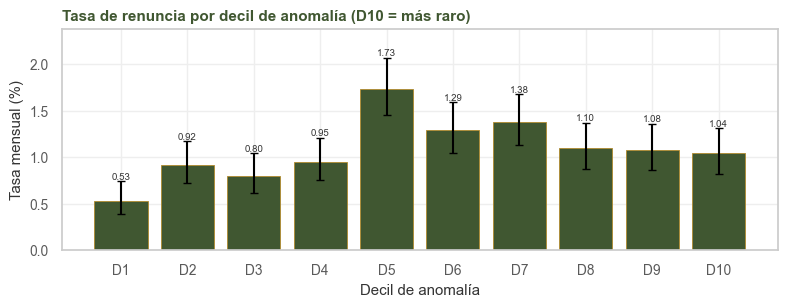

decil           D1       D2      D3       D4       D5       D6       D7      D8       D9      D10
filas      6754.00  6758.00  6781.0  6720.00  6752.00  6755.00  6751.00  6754.0  6754.00  6751.00
renuncias    36.00    62.00    54.0    64.00   117.00    87.00    93.00    74.0    73.00    70.00
tasa_%        0.53     0.92     0.8     0.95     1.73     1.29     1.38     1.1     1.08     1.04
             1 % más raro  resto
edad                 36.6   37.4
antig_meses          95.5   58.2
linea en el 1 % más raro: {'industrial': 44.0, 'palma': 23.0, 'banano': 15.0, 'transporte': 11.0}
tipo_unidad en el 1 % más raro: {'area_funcional': 88.0, 'planta_industrial': 9.0, 'finca_banano': 3.0}
contrato en el 1 % más raro: {'Termino Indefinido': 77.0, 'Termino Fijo': 23.0}


In [6]:
iso = IsolationForest(n_estimators=300, contamination='auto', random_state=SEMILLA, n_jobs=-1)
puntaje = -iso.fit(X).score_samples(X)
decil = pd.qcut(puntaje, 10, labels=[f'D{i}' for i in range(1, 11)])
t = tasa_ic(pd.DataFrame({OBJETIVO: y, 'decil': decil}), 'decil')

fig, ax = plt.subplots(figsize=(8, 3.2))
error = [t['tasa_%'] - t.ic_bajo, t.ic_alto - t['tasa_%']]
ax.bar(t.index.astype(str), t['tasa_%'], yerr=error, color=VERDE, capsize=3, **BORDE)
for xi, v, alto in zip(range(len(t)), t['tasa_%'], t.ic_alto):
    ax.text(xi, alto, f'{v:.2f}', ha='center', va='bottom', fontsize=7, color=TINTA)
ax.set_ylim(0, t.ic_alto.max() * 1.15)
ax.set(title='Tasa de renuncia por decil de anomalía (D10 = más raro)',
       xlabel='Decil de anomalía', ylabel='Tasa mensual (%)')
plt.tight_layout()
plt.show()
print(t[['filas', 'renuncias', 'tasa_%']].T.to_string())

top = puntaje >= np.quantile(puntaje, 0.99)
perfil = pd.DataFrame({'1 % más raro': tr[top][['edad', 'antig_meses']].mean(),
                       'resto': tr[~top][['edad', 'antig_meses']].mean()}).round(1)
print(perfil.to_string())
for v in ['linea', 'tipo_unidad', 'contrato']:
    reparto = (100 * tr[top][v].value_counts(normalize=True)).round(0).head(4)
    print(f'{v} en el 1 % más raro:', reparto.to_dict())

Las filas más raras no renuncian más: la tasa del decil más anómalo (1,0 %) es la media. El 1 % más
raro es sobre todo personal de oficina con mucha antigüedad y contrato indefinido, un perfil poco
frecuente pero estable. El decil más típico (D1) tiene la tasa más baja (0,5 %). Las observaciones
anómalas corresponden a puestos poco comunes y se conservan.

## Conglomerados

Aplicamos k-medias sobre los 10 primeros componentes y buscamos el número de grupos con el
coeficiente de silueta, sobre una muestra de 6.000 filas.

In [7]:
idx = rng.choice(len(Z), 6000, replace=False)
silueta = {}
for k in range(2, 9):
    etiquetas = KMeans(k, n_init=10, random_state=SEMILLA).fit_predict(Z[idx])
    silueta[k] = silhouette_score(Z[idx], etiquetas)
print('silueta por k:', {k: round(v, 3) for k, v in silueta.items()})

k = max(silueta, key=silueta.get)
km = KMeans(k, n_init=10, random_state=SEMILLA).fit(Z)
grupos = tr.assign(grupo=km.labels_).groupby('grupo').agg(
    filas=(OBJETIVO, 'size'),
    renuncias=(OBJETIVO, 'sum'),
    edad=('edad', 'mean'),
    antig=('antig_meses', 'mean'),
    pct_fijo=('contrato', lambda s: 100 * (s == 'Termino Fijo').mean()),
    linea=('linea', lambda s: s.value_counts().index[0]),
    tipo_unidad=('tipo_unidad', lambda s: s.value_counts().index[0]),
)
grupos['tasa_%'] = 100 * grupos.renuncias / grupos.filas
grupos.round(1).sort_values('tasa_%', ascending=False)

silueta por k: {2: 0.313, 3: 0.341, 4: 0.392, 5: 0.428, 6: 0.461, 7: 0.493, 8: 0.51}


grupo,filas,renuncias,edad,antig,pct_fijo,linea,tipo_unidad,tasa_%
6,6614,174,39.0,76.4,32.0,banano,finca_banano,2.6
0,8081,105,35.2,53.2,62.1,palma,area_funcional,1.3
4,3123,36,40.1,37.4,41.6,transporte,area_funcional,1.2
3,6707,75,35.2,58.5,61.7,palma,planta_industrial,1.1
2,33268,269,38.0,56.0,54.4,palma,finca_palma,0.8
5,2890,22,38.9,59.9,64.3,palma,area_funcional,0.8
1,6135,45,34.5,69.0,44.4,palma,area_funcional,0.7
7,712,4,42.3,77.7,55.5,ganaderia,hacienda_ganadera,0.6


La silueta aumenta con k en todo el rango probado (2 a 8): los datos no tienen un número
natural de grupos. Se adoptan k = 8 grupos con fines descriptivos; los grupos resultantes son sobre
todo cortes organizacionales.

## Síntesis

- La única redundancia entre numéricas es edad y antigüedad (0,6). Las redundancias fuertes entre
  categóricas son anidamientos por construcción (sociedad y línea, oficio y familia) y se manejan
  con regularización.
- La estructura principal de los datos es organizacional (línea, tipo de unidad).
- Ni los conglomerados ni las anomalías aíslan a quienes renuncian: el riesgo resulta de combinar
  señales moderadas. Por eso el modelo base es una logística, que suma señales, antes de modelos que
  busquen interacciones complejas.